In [1]:
# Basic setup and imports
# Keep the notebook stable on Windows/Jupyter.
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
os.environ['PYTHONUTF8'] = '1'
os.environ['PYTHONIOENCODING'] = 'utf-8'
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
sns.set_theme(style='whitegrid', context='notebook')

print('Libraries loaded successfully.')


Libraries loaded successfully.


In [2]:
# Load Titanic train/test data.
# Prefer Kaggle input paths when running on Kaggle.
train_path = '../data/raw/train.csv'
test_path = '../data/raw/test.csv'

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        full_path = os.path.join(dirname, filename)
        if filename == 'train.csv':
            train_path = full_path
        elif filename == 'test.csv':
            test_path = full_path

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')


Train shape: (891, 12)
Test shape:  (418, 11)


In [3]:
# Advanced EDA summary tables.
# Build a compact analysis table from the training set only.
eda = train.copy()

eda['Title'] = eda['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
eda['Title'] = eda['Title'].replace({
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
})
eda['FamilySize'] = eda['SibSp'] + eda['Parch'] + 1
eda['IsAlone'] = (eda['FamilySize'] == 1).astype(int)
eda['HasCabin'] = eda['Cabin'].notna().astype(int)
eda['AgeBand'] = pd.cut(eda['Age'], bins=[0, 16, 32, 48, 64, 80])
eda['FareBand'] = pd.qcut(eda['Fare'].fillna(eda['Fare'].median()), q=4, duplicates='drop')

print('Missing values in train:')
print(train.isna().sum().sort_values(ascending=False))

print('\nSurvival rate by sex:')
print(eda.groupby('Sex')['Survived'].mean().sort_values(ascending=False))

print('\nSurvival rate by passenger class:')
print(eda.groupby('Pclass')['Survived'].mean().sort_index())

print('\nTop titles by count:')
print(eda['Title'].value_counts().head(10))

print('\nSurvival rate by title:')
print(eda.groupby('Title')['Survived'].mean().sort_values(ascending=False))


Missing values in train:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

Survival rate by sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Top titles by count:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Survival rate by title:
Title
Mrs       0.793651
Miss      0.702703
Master    0.575000
Rare      0.347826
Mr        0.156673
Name: Survived, dtype: float64


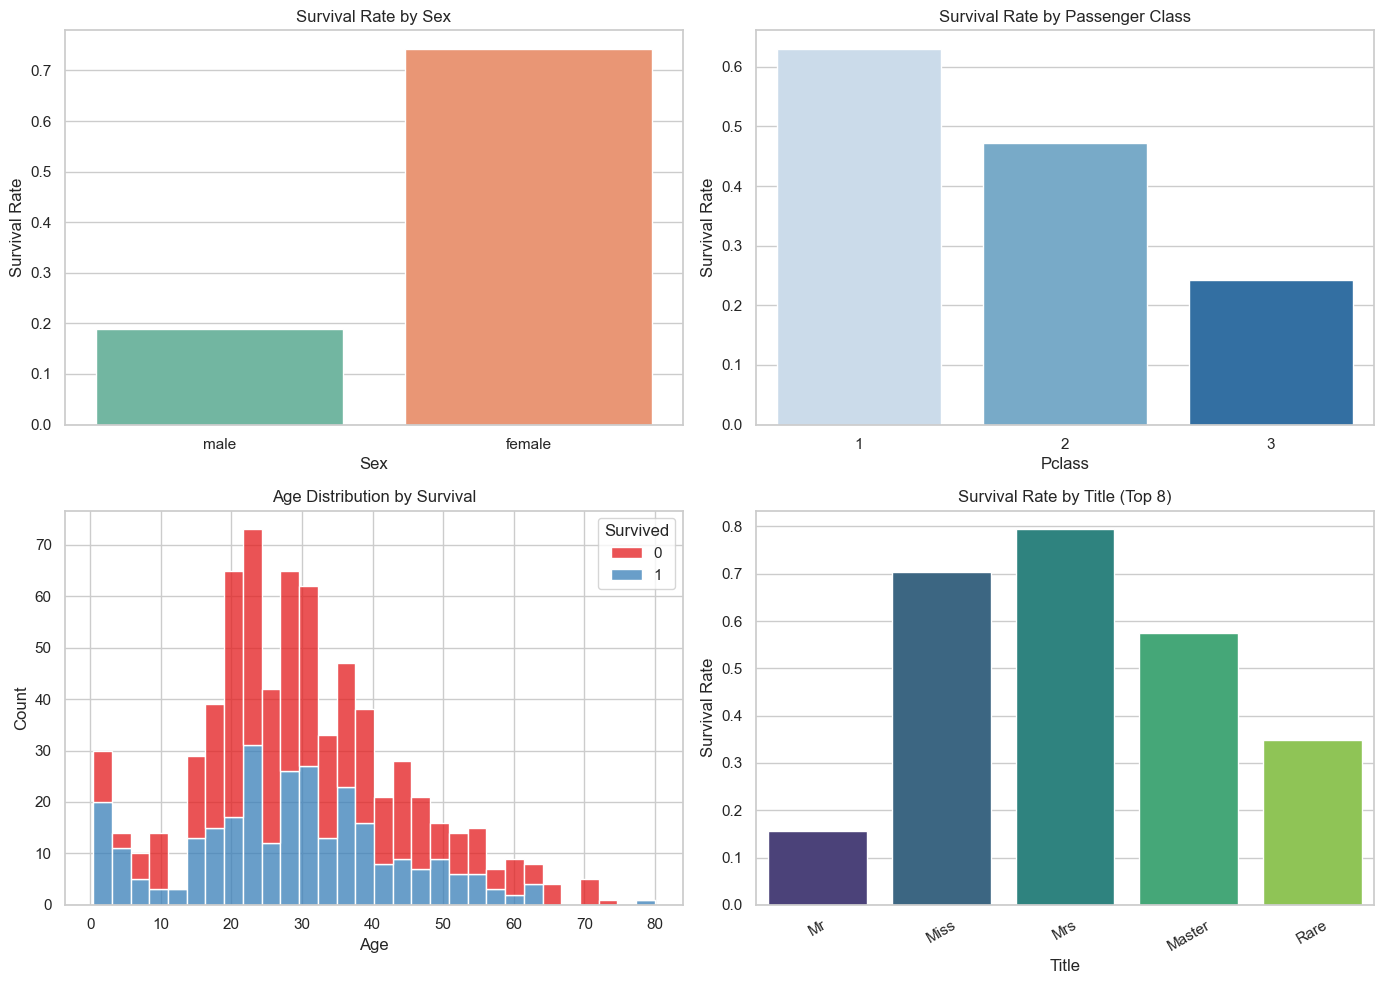

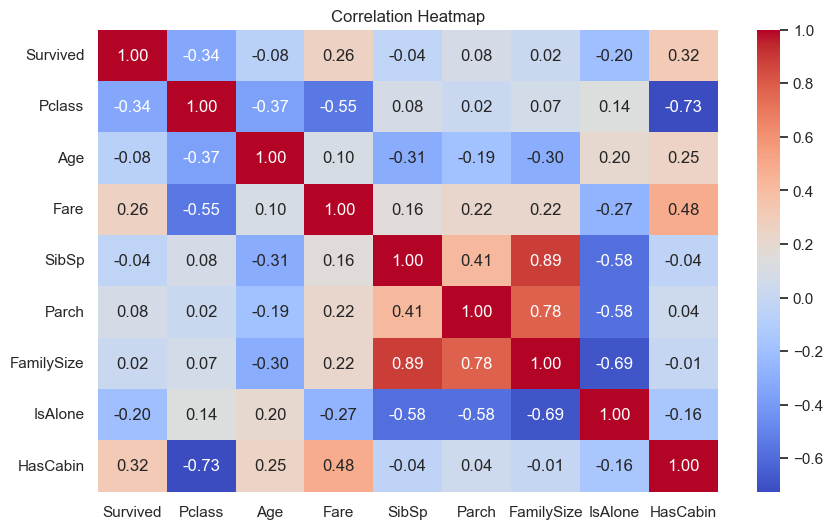

In [4]:
# Advanced EDA charts.
# Focus on the strongest Titanic signals before modeling.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=eda, x='Sex', y='Survived', ax=axes[0, 0], errorbar=None, palette='Set2')
axes[0, 0].set_title('Survival Rate by Sex')
axes[0, 0].set_ylabel('Survival Rate')

sns.barplot(data=eda, x='Pclass', y='Survived', ax=axes[0, 1], errorbar=None, palette='Blues')
axes[0, 1].set_title('Survival Rate by Passenger Class')
axes[0, 1].set_ylabel('Survival Rate')

sns.histplot(data=eda, x='Age', hue='Survived', bins=30, multiple='stack', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Age Distribution by Survival')

title_order = eda['Title'].value_counts().head(8).index
sns.barplot(
    data=eda[eda['Title'].isin(title_order)],
    x='Title', y='Survived', order=title_order,
    ax=axes[1, 1], errorbar=None, palette='viridis'
)
axes[1, 1].set_title('Survival Rate by Title (Top 8)')
axes[1, 1].set_ylabel('Survival Rate')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

corr_features = eda[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'HasCabin']].copy()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_features.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


In [5]:
# Create a small set of useful features.
# Then build the preprocessing pipeline for numeric and categorical columns.
def add_features(df):
    df = df.copy()

    # Extract passenger titles from names.
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace({
        'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
        'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
        'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
        'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
    })

    # Add a few simple family and cabin signals.
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['HasCabin'] = df['Cabin'].notna().astype(int)

    return df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'SibSp', 'Parch',
               'Title', 'FamilySize', 'IsAlone', 'HasCabin']]

X = add_features(train)
y = train['Survived'].astype(int)
X_test = add_features(test)

numeric_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'Pclass', 'IsAlone', 'HasCabin']
categorical_features = ['Sex', 'Embarked', 'Title']

# Median for numeric columns, most frequent value for categoricals.
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print(f'Feature table shape: {X.shape}')


Feature table shape: (891, 11)


In [6]:
# Compare a few strong baseline models.
# Keep the search space small and readable.
models = {
    'Logistic Regression': LogisticRegression(C=0.5, max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=5, min_samples_split=10,
        min_samples_leaf=4, random_state=RANDOM_STATE, n_jobs=1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
    )
}

scores = {}

# Evaluate each model with cross validation.
for name, model in models.items():
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    cv_score = cross_val_score(pipeline, X, y, cv=CV, scoring='accuracy', n_jobs=1).mean()
    scores[name] = cv_score
    print(f'{name:<20} -> CV Accuracy: {cv_score:.4f}')

# Blend the three models with soft voting.
voting_model = VotingClassifier(
    estimators=[
        ('lr', models['Logistic Regression']),
        ('rf', models['Random Forest']),
        ('gb', models['Gradient Boosting'])
    ],
    voting='soft'
)

voting_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', voting_model)
])

voting_score = cross_val_score(voting_pipeline, X, y, cv=CV, scoring='accuracy', n_jobs=1).mean()
scores['Soft Voting'] = voting_score
print(f'{"Soft Voting":<20} -> CV Accuracy: {voting_score:.4f}')

best_model_name = max(scores, key=scores.get)
print(f'\nBest model: {best_model_name} ({scores[best_model_name]:.4f})')


Logistic Regression  -> CV Accuracy: 0.8283
Random Forest        -> CV Accuracy: 0.8316
Gradient Boosting    -> CV Accuracy: 0.8395
Soft Voting          -> CV Accuracy: 0.8373

Best model: Gradient Boosting (0.8395)


In [7]:
# Fit the best pipeline on the full training set.
# Then create the Kaggle submission file.
final_pipelines = {
    'Logistic Regression': Pipeline([('prep', preprocessor), ('model', models['Logistic Regression'])]),
    'Random Forest': Pipeline([('prep', preprocessor), ('model', models['Random Forest'])]),
    'Gradient Boosting': Pipeline([('prep', preprocessor), ('model', models['Gradient Boosting'])]),
    'Soft Voting': voting_pipeline
}

final_model = final_pipelines[best_model_name]
final_model.fit(X, y)
predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions.astype(int)
})

submission.to_csv('submission.csv', index=False)
print('submission.csv saved successfully.')
submission.head(10)


submission.csv saved successfully.


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0
